# **`PROGRAM - 1`**

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
df = pd.read_csv("/content/housing.csv")

target_col = "median_house_value"
feature_cols = [
    "longitude",
    "latitude",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income",

]
drop_cols = [target_col]
feature_df_num = df.drop(columns=drop_cols).select_dtypes(include=[np.number])
feature_df_cat = df.drop(columns=drop_cols).select_dtypes(include=[object])
features_df = df[feature_cols]

if features_df.isnull().any().any():
    features_df = features_df.fillna(features_df.median())

X = features_df.values
y = df[target_col].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]



def gradient_descent(X, y, lr=0.01, n_iters=1000):

    m, n = X.shape

    theta = np.zeros((n, 1))
    losses = []

    for i in range(n_iters):

        # Prediction
        y_pred = X @ theta      # @ means matrix multiplication

        # Error
        error = y_pred - y

        # Mean Squared Error (MSE) loss
        loss = (1 / (2 * m)) * np.sum(error ** 2)
        losses.append(loss)

        # Gradient of MSE with respect to theta
        gradient = (1 / m) * (X.T @ error)

        # Update rule
        theta -= lr * gradient

        if i % 100 == 0:
            print(f"Iteration {i:4d} | Loss: {loss:.4f}")

    return theta, losses


theta, losses = gradient_descent(
    X_train_b,
    y_train,
    lr=0.01,
    n_iters=1000
)

Iteration    0 | Loss: 28148711615.5157
Iteration  100 | Loss: 6594261728.1318
Iteration  200 | Loss: 3624726180.1378
Iteration  300 | Loss: 3136923488.1644
Iteration  400 | Loss: 2994315332.1735
Iteration  500 | Loss: 2910289142.5664
Iteration  600 | Loss: 2844600530.8894
Iteration  700 | Loss: 2790140403.6982
Iteration  800 | Loss: 2744508974.9365
Iteration  900 | Loss: 2706180263.5230


In [4]:


y_pred = X_test_b @ theta

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nFinal weights (theta):")
print(theta.ravel())

print(f"\nTest MSE : {mse:.4f}")
print(f"Test R^2 : {r2:.4f}")



from sklearn.linear_model import LinearRegression

sk_model = LinearRegression()

sk_model.fit(X_train, y_train)

sk_pred = sk_model.predict(X_test)


Final weights (theta):
[207185.74888449 -51092.79205519 -55582.99485211  -9593.50682245
  20141.52358115 -33113.70154356  23094.84557752  76685.30316381]

Test MSE : 5463042007.1792
Test R^2 : 0.5831



sklearn LinearRegression R^2: 0.6056

Saved plots to gradient_descent_plots.png


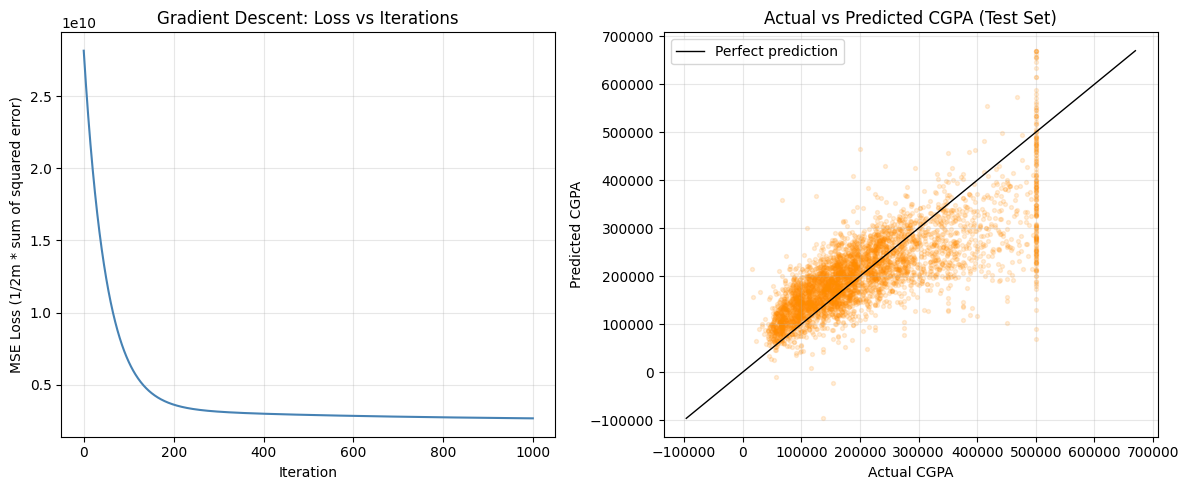

In [5]:


from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

sk_model = LinearRegression()

sk_model.fit(X_train, y_train)
sk_pred = sk_model.predict(X_test)

print(f"\nsklearn LinearRegression R^2: {r2_score(y_test, sk_pred):.4f}")


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) Gradient descent loss curve — shows convergence over iterations
axes[0].plot(range(len(losses)), losses, color="steelblue")

axes[0].set_title("Gradient Descent: Loss vs Iterations")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("MSE Loss (1/2m * sum of squared error)")
axes[0].grid(alpha=0.3)

# (b) Actual vs Predicted CGPA on the test set
axes[1].scatter(y_test, y_pred, alpha=0.15, s=8, color="darkorange")

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

axes[1].plot(
    lims,
    lims,
    color="black",
    linestyle="-",
    linewidth=1,
    label="Perfect prediction"
)

axes[1].set_title("Actual vs Predicted CGPA (Test Set)")
axes[1].set_xlabel("Actual CGPA")
axes[1].set_ylabel("Predicted CGPA")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

plt.savefig("gradient_descent_plots.png", dpi=150)

print("\nSaved plots to gradient_descent_plots.png")

plt.show()